In [47]:
import torch
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets, surface, plotting

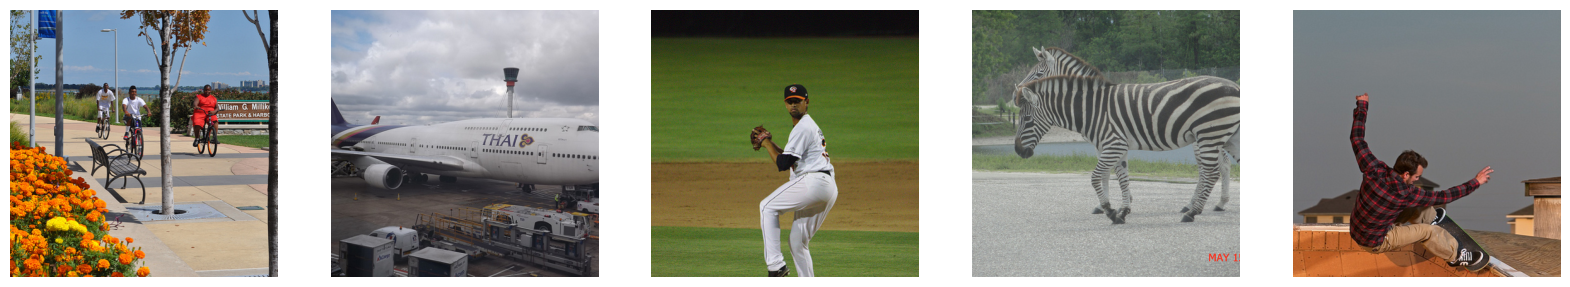

In [14]:
# we proceed by loading all images into a single tensor

# read image ids from filenames
image_ids = [filename.split('.')[0] for filename in os.listdir('../sample_data/images') if filename.endswith('.png')] 

# load images into tensor
images = []
for image_id in image_ids:
    image_path = os.path.join('../sample_data/images', f'{image_id}.png')
    image = Image.open(image_path).convert('RGB')
    image_tensor = torch.tensor(np.array(image)).permute(2, 0, 1)  # Convert to CxHxW
    images.append(image_tensor)

# Stack all images into a single tensor
images_tensor = torch.stack(images)  # Shape: (N, C, H, W

# To test this, visualize first 5 images from the tensor as a single row
plt.figure(figsize=(20, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images_tensor[i].permute(1, 2, 0).numpy())  # Convert back to HxWxC for display
    plt.axis('off')
plt.show()

In [ ]:
# then, we load the raw CLIP token embeddings
token_embeddings = torch.load('../sample_data/sdxl_clip_embeddings.pt')

token_embeddings.shape  # N x T x D where N is the number of images, T is the number of tokens, and D is the embedding dimension

torch.Size([50, 256, 1664])

In [17]:
# The tokens represent 16x16 image patches. We reshape the token embeddings to match the spatial layout of the image patches.
token_embeddings_reshaped = token_embeddings.view(token_embeddings.size(0), 16, 16, token_embeddings.size(2))

token_embeddings_reshaped.shape  # N x 16 x 16 x D

torch.Size([50, 16, 16, 1664])

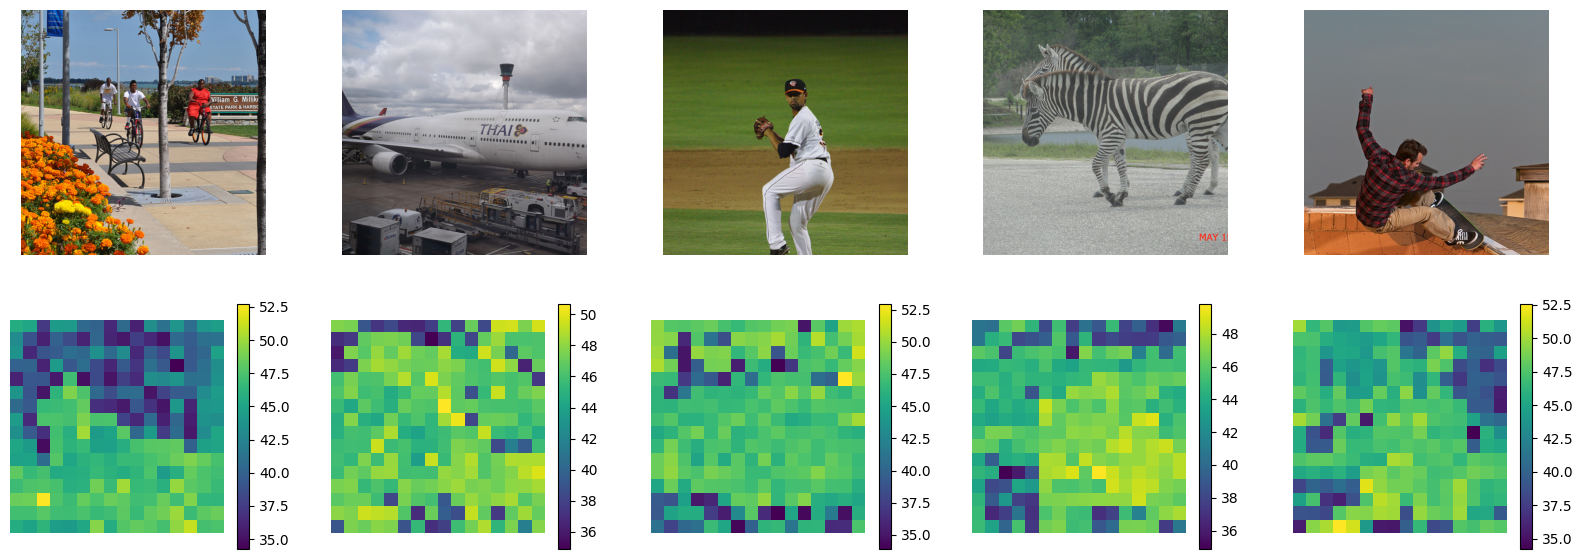

In [27]:
# start our analysis by simply computing the L2 norm of the token embeddings for each image. And visualize the norms as a heatmap for each image.
token_norms = token_embeddings_reshaped.norm(dim=-1)

# Visualize the token norms as heatmaps below their respective images. We will visualize the first 5 images and their corresponding token norm heatmaps.
plt.figure(figsize=(20, 7))
for i in range(5):
    # Display the image
    plt.subplot(2, 5, i + 1)
    plt.imshow(images_tensor[i].permute(1, 2, 0).numpy())
    plt.axis('off')
    
    # Display the token norm heatmap
    plt.subplot(2, 5, i + 6)
    plt.imshow(token_norms[i].numpy(), cmap='viridis', interpolation='nearest')
    plt.colorbar()
    plt.axis('off')

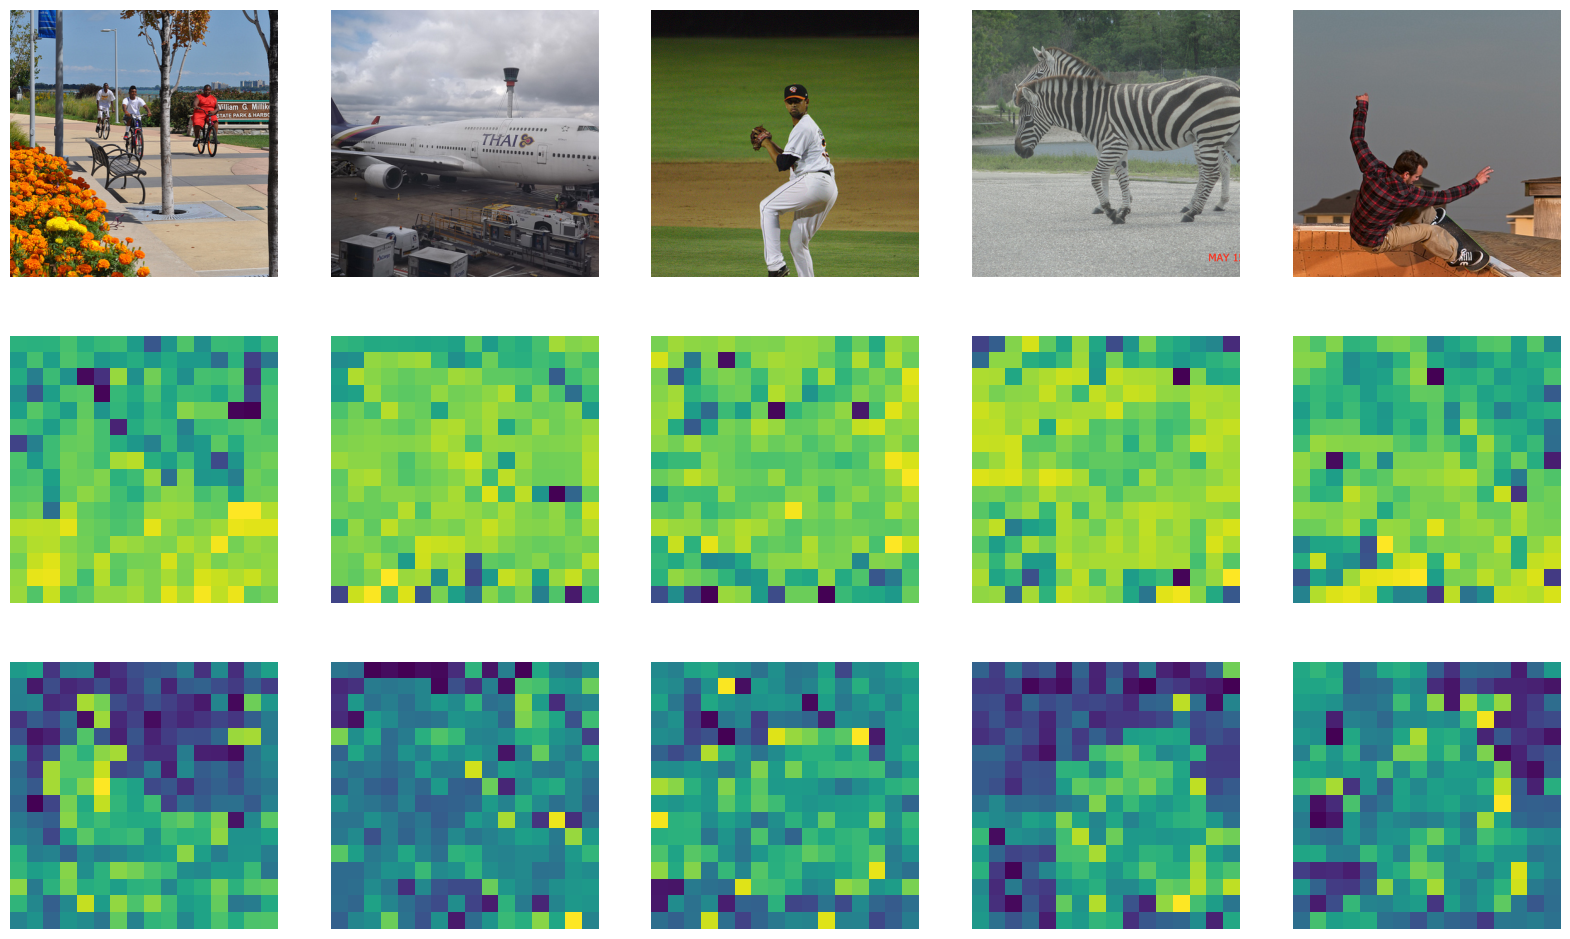

In [33]:
# We do not see a lot of structure, but we also do not see any high-norm outliers.
# We will now compute PCA on the token embeddings to see if we can find any structure in the data.
def pca(X, n_components):
    original_dtype = X.dtype

    if X.dtype in (torch.float16, torch.bfloat16):
        X = X.float()

    mean = X.mean(dim=0)
    X_centered = X - mean

    U, S, Vh = torch.linalg.svd(X_centered, full_matrices=False)

    components = Vh[:n_components]
    X_pca = X_centered @ components.T

    variance = (S ** 2) / (len(X) - 1)
    explained_variance_ratio = variance[:n_components] / variance.sum()

    # Cast outputs back to the original dtype
    return X_pca.to(original_dtype), components.to(original_dtype), explained_variance_ratio.to(original_dtype)

# flatten the token embeddings to (N*T, D) for PCA
token_embeddings_flattened = token_embeddings_reshaped.view(-1, token_embeddings_reshaped.size(-1))

# perform PCA to reduce the dimensionality of the token embeddings to 2D for visualization
token_embeddings_pca, components, explained_variance_ratio = pca(token_embeddings_flattened, n_components=2)

# reshape the PCA results back to (N, 16, 16, 2) for visualization
token_embeddings_pca_reshaped = token_embeddings_pca.view(token_embeddings_reshaped.size(0), 16, 16, 2)

# Analogous to the token norms, we can visualize the PCA results as heatmaps for each image. We will visualize the first 5 images and their corresponding PCA heatmaps.
plt.figure(figsize=(20, 12))
for i in range(5):
    # Display the image
    plt.subplot(3, 5, i + 1)
    plt.imshow(images_tensor[i].permute(1, 2, 0).numpy())
    plt.axis('off')
    
    # Display the PCA heatmap for the first principal component
    plt.subplot(3, 5, i + 6)
    plt.imshow(token_embeddings_pca_reshaped[i, :, :, 0].numpy(), cmap='viridis', interpolation='nearest')
    # plt.colorbar()
    plt.axis('off')

    # Display the PCA heatmap for the second principal component
    plt.subplot(3, 5, i + 11)
    plt.imshow(token_embeddings_pca_reshaped[i, :, :, 1].numpy(), cmap='viridis', interpolation='nearest')
    # plt.colorbar()
    plt.axis('off')
plt.show()

In [3]:
# load fMRI zscores
zscores = torch.load('../sample_data/fmri_zscores.pt')

print(zscores.shape)  # N x T x V where N is the number of images T is the number of trials per image and V is the number of voxels in the brain

# NeuroFlow testing procedure uses the average across trials for each image, so we will do the same here.
zscores_mean = zscores.mean(dim=1)  # N x V

print(zscores_mean.shape)  # N x V


torch.Size([50, 3, 15724])
torch.Size([50, 15724])


TODO: better understanding of surface plots and which background to best use with NSD data
- https://nilearn.github.io/stable/plotting/index.html
- https://cvnlab.slite.page/p/X_7BBMgghj/ROIs

see here to better understand fMRI data format:
https://cvnlab.slite.page/p/6CusMRYfk0#bd0cbb9f

Q: which surface mesh to use for visualization? Does there exist subject-specifc ones?

In [44]:
def visualize_fmri_zscores(
    zscores: np.ndarray, # N x V
    roi_mask: str, # path to the ROI mask file
    indices: np.ndarray = np.arange(5), # indices of images to visualize
    threshold: float = 0.1, # threshold for zscores
    verbose: bool = False, # whether to print debug information
    figsize: tuple = (20, 5), # size of the figure
    out_dir: str = None # output directory for the visualizations
):
    roi_mask_img = nib.load(roi_mask)
    assert len(indices) <= zscores.shape[0], "Number of indices exceeds number of images"

    zscores_filtered = zscores[indices]


    roi_data = roi_mask_img.get_fdata()
    
    # Get a standard surface mesh (fsaverage is the common default)
    fsaverage = datasets.fetch_surf_fsaverage()
    bg_right = fsaverage.sulc_right
    # bg_left = surface.vol_to_surf('../sample_data/roi/corticalsulc.nii.gz', fsaverage.pial_left)
    
    fig, axes = plt.subplots(1, len(indices), figsize=figsize, subplot_kw={'projection': '3d'})
    for i, zscore in enumerate(zscores_filtered):
        zscores_restored = np.zeros(roi_data.shape)  # Initialize an array to hold the restored zscores 
        zscores_restored[roi_data > 0] = zscore  # Fill in the zscores for the current image

        zscores_img = nib.Nifti1Image(zscores_restored, affine=roi_mask_img.affine)

        # Project your volume onto the surface (left and right hemispheres separately)
        # texture_left = surface.vol_to_surf(zscores_img, fsaverage.pial_left)
        texture_right = surface.vol_to_surf(zscores_img, fsaverage.pial_right)

        # Plot the right hemisphere
        plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, hemi="right", view="medial",
                              bg_map=bg_right, threshold=threshold, axes=axes[i], colorbar=verbose, alpha=0.7) 

        del zscores_restored, zscores_img, texture_right 

    if out_dir is not None: 
        plt.savefig(os.path.join(out_dir, f'zscore_visualization.png'))
        plt.close(fig)
    else:
        plt.show()

    del roi_mask_img, fsaverage, bg_right, axes, fig

/Users/frederik/Repositories/cognition-computation/venv/lib/python3.11/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/frederik/Repositories/cognition-computation/venv/lib/python3.11/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/frederik/Repositories/cognition-computation/venv/lib/python3.11/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/frederik/Repositories/cognition-computation/venv/lib/python3.11/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/frederik/Repositories/cognition-computation/venv/lib/python3.11/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


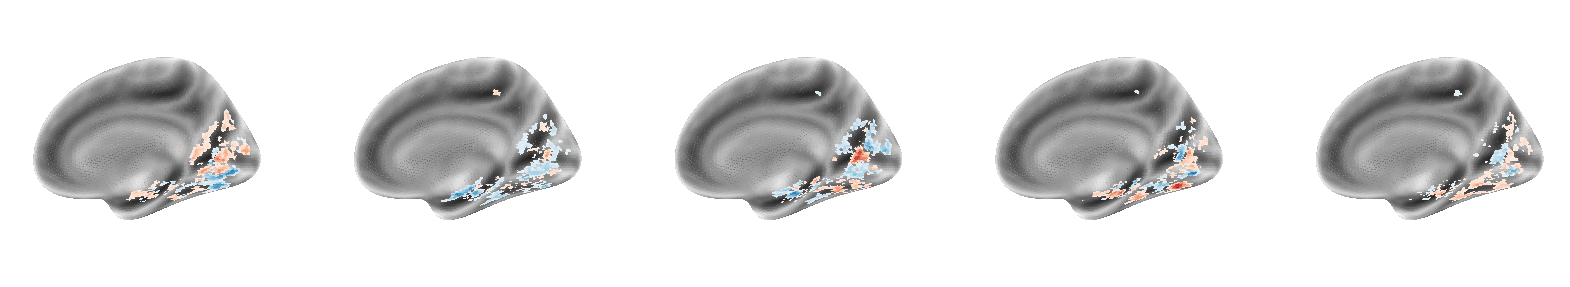

In [45]:
visualize_fmri_zscores(zscores_mean.numpy(), '../sample_data/roi/nsdgeneral.nii.gz', indices=np.arange(5))


In [48]:
import cortex

In [49]:
cortex.webshow(cortex.Volume.random("S1", "fullhead"))

Generating new ctm file...
wm
wm
Generating curvature surface info...


/Users/frederik/Repositories/cognition-computation/venv/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve


inflated
inflated
Started server on port 3217
Stopping server


<JS: window.viewer>

In [53]:
# This frustratingly requires the full FreeSufer software to be installed. 
# cortex.freesurfer.import_subj('subj01', freesurfer_subject_dir='../sample_data/freesurfer/')
